# Oda Doluluğu Veri Seti ile Sınıflandırma, Regresyon ve Kümeleme
BMM4111 — Makine Öğrenmesi Dönem Ödevi

Bu çalışmada aynı odadan toplanan sensör verilerini üç farklı problem için kullandım.
Sınıflandırmada kişi sayısını 0, 1, 2 ve 3 sınıfları olarak tahmin ettim.
Regresyonda diğer sensörlerden CO₂ miktarını tahmin ettim. Kümelemede benzer ortam koşullarını grupladım.

Veri kaynağı: [UCI Room Occupancy Estimation](https://archive.ics.uci.edu/dataset/864/room+occupancy+estimation).
Singh ve Chaudhari (2018), DOI: 10.24432/C5P605. Lisans: CC BY 4.0.

## 1. Kütüphaneler
Çalışmada pandas, NumPy, Matplotlib ve scikit-learn kullandım. Tekrarlanabilirlik için rastgelelik tohumunu 42 olarak belirledim.
Çalıştırma adımları README dosyasında yer alıyor.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             ConfusionMatrixDisplay, silhouette_score)

SEED = 42
plt.rcParams['figure.figsize'] = (8, 4)
print('scikit-learn sürümü:', sklearn.__version__)

scikit-learn sürümü: 1.9.1


## 2. Veriyi okuma
CSV dosyasını okuyup tarih ve saat alanlarını birleştirdim. Her satır, odada belirli bir anda alınan sensör ölçümlerini temsil ediyor.

In [2]:
proje = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
dosya = proje / 'data/raw/Occupancy_Estimation.csv'
if not dosya.exists():
    dosya = Path('Occupancy_Estimation.csv')  # Colab'a yüklenen dosya

sonuc_klasoru = proje / 'outputs'
sekil_klasoru = sonuc_klasoru / 'figures'
sekil_klasoru.mkdir(parents=True, exist_ok=True)

veri = pd.read_csv(dosya)
veri['zaman'] = pd.to_datetime(veri['Date'] + ' ' + veri['Time'])
veri = veri.sort_values('zaman').reset_index(drop=True)
print('Satır sayısı:', len(veri))
veri.head()

Satır sayısı: 10129


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,zaman
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,2017-12-22 10:50:42
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,2017-12-22 10:51:13
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,2017-12-22 10:51:44


### Eksik ve tekrar eden kayıtlar
Önce eksik değerleri, tekrar eden satırları ve sınıfların tarihlere göre dağılımını kontrol ettim.

In [3]:
print('Eksik hücre sayısı:', veri.isna().sum().sum())
print('Tekrar eden satır sayısı:', veri.duplicated().sum())
print('Farklı tarih sayısı:', veri['Date'].nunique())
display(veri['Room_Occupancy_Count'].value_counts().sort_index())
display(pd.crosstab(veri['Date'], veri['Room_Occupancy_Count']))

Eksik hücre sayısı: 0
Tekrar eden satır sayısı: 0
Farklı tarih sayısı: 7


Room_Occupancy_Count
0    8228
1     459
2     748
3     694
Name: count, dtype: int64

Room_Occupancy_Count,0,1,2,3
Date,,,,
2017/12/22,637,205,257,363
2017/12/23,1997,254,398,130
2017/12/24,1064,0,0,0
2017/12/25,1716,0,0,0
2017/12/26,1063,0,0,0
2018/01/10,703,0,93,201
2018/01/11,1048,0,0,0


Veride 10.129 kayıt buldum. Eksik veya tamamen tekrar eden satır olmadığı için bu nedenlerle kayıt silmedim.
Kaynak açıklamasında dört gün belirtilmesine rağmen CSV'de 7 farklı tarih bulunuyor.
“0 kişi” sınıfı çoğunlukta olduğu için model seçiminde her sınıfa eşit ağırlık veren macro-F1 kullandım.

## 3. Girdiler ve hedefler
| Alan | Anlamı | Tür |
|---|---|---|
| S1–S4 Temp | Sıcaklık (°C) | Sayısal |
| S1–S4 Light | Aydınlık (lux) | Sayısal |
| S1–S4 Sound | Ses sensörü çıkışı (volt) | Sayısal |
| S6–S7 PIR | Hareket yok / var | İkili kategorik |

Toplam 14 özellik kullandım. PIR sütunları zaten 0/1 kodlu olduğu için ek kodlama yapmadım.
Kişi sayısını dört kategorili sınıflandırma hedefi olarak ele aldım. CO₂ fiziksel olarak sürekli bir büyüklük olduğu için regresyon hedefi olarak seçtim; dosyada tam sayı hassasiyetinde kaydedilmiş.

Veri sızıntısını önlemek için iki hedefi (`Room_Occupancy_Count`, `S5_CO2`) ve CO₂'den türetilen `S5_CO2_Slope` sütununu bütün görevlerde girdilerden çıkardım. Tarih ve saati yalnızca veriyi bölmek için kullandım.

In [ ]:
sayisal_sutunlar = [
    'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp',
    'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light',
    'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound'
]
kategorik_sutunlar = ['S6_PIR', 'S7_PIR']
ozellikler = sayisal_sutunlar + kategorik_sutunlar

# Özellik matrisi ve hedef değişkenleri tanımladık
X = veri[ozellikler]
y_sinif = veri['Room_Occupancy_Count']
y_reg = veri['S5_CO2']

## 4. Eğitim ve test ayrımı
Yakın zamanlarda alınan ölçümler birbirine benzediği için kayıtları iki saatlik bloklara ayırdım.
`StratifiedGroupKFold` ile aynı bloğun eğitim ve teste dağılmasını önledim; sınıf oranlarını da mümkün olduğunca korudum.
Beş parçadan ilkini test, kalanlarını eğitim olarak ayırdım. Bölmeyi test puanına göre değiştirmedim.

In [ ]:
# Bloklar oluşturmak için zaman sütununu 2 saatlik aralıklara yuvarlar.
veri['blok'] = veri['zaman'].dt.floor('2h')

# 5 bölmeye böler ve her bölmede sınıf dağılımını ve blokları korur.
bolucu = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# ilk bölmeyi alır ve eğitim ve test indekslerini döndürür.
egitim_index, test_index = next(bolucu.split(X, y_sinif, groups=veri['blok']))

### Zaman blokları arasında tampon
Blok sınırlarında birbirine yakın ölçümler kalabileceği için test kayıtlarına 15 dakika veya daha yakın eğitim kayıtlarını çıkardım.
Aynı işlemi CV'de eğitim ve doğrulama arasında da uyguladım.

In [ ]:
# verilen eğitim indekslerinden, test veya o anki CV doğrulama kayıtlarına yakın olanları çıkarır.
def yakin_kayitlari_cikar(egitim_index, kontrol_index):
    egitim_zamani = veri.loc[egitim_index, 'zaman']
    kullan = pd.Series(True, index=egitim_index)

    # kontrol_index: test veya o anki CV doğrulama kayıtları
    kontrol_verisi = veri.loc[kontrol_index]
    for blok, kayitlar in kontrol_verisi.groupby('blok'):
        baslangic = kayitlar['zaman'].min() - pd.Timedelta(minutes=15)
        bitis = kayitlar['zaman'].max() + pd.Timedelta(minutes=15)
        yakin = egitim_zamani.between(baslangic, bitis)
        # & ~yakin: yakın olanları false yapar, yani çıkarır.
        kullan = kullan & ~yakin

    return kullan[kullan].index.to_numpy()

egitim_index = yakin_kayitlari_cikar(egitim_index, test_index)

# Eğitim ve test veri setlerini oluşturma
X_train = X.loc[egitim_index]
X_test = X.loc[test_index]
y_sinif_train = y_sinif.loc[egitim_index]
y_sinif_test = y_sinif.loc[test_index]
y_reg_train = y_reg.loc[egitim_index]
y_reg_test = y_reg.loc[test_index]

print('Eğitim:', len(X_train), 'Test:', len(X_test))
print('Tamponda bırakılan:', len(veri) - len(X_train) - len(X_test))

# Eğitim ve test veri setlerinde blokların kesişmediğini doğrulama
assert set(veri.loc[egitim_index, 'blok']).isdisjoint(veri.loc[test_index, 'blok'])

Eğitim: 7720 Test: 1976
Tamponda bırakılan: 433


,Eğitim,Test
Room_Occupancy_Count,,
0,6367,1580
1,288,142
2,579,74
3,486,180


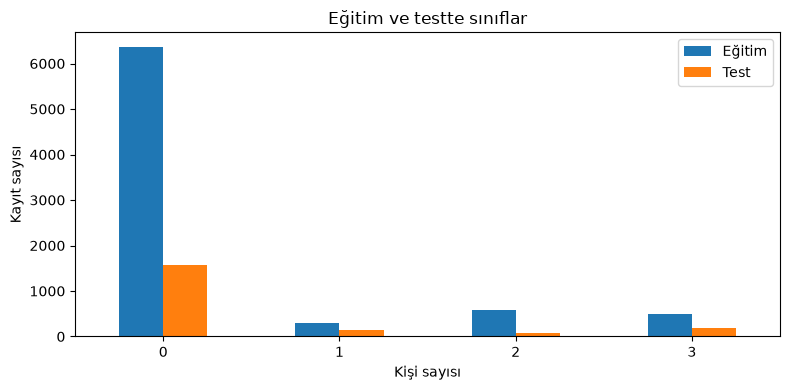

In [28]:
sinif_dagilimi = pd.DataFrame({
    'Eğitim': y_sinif_train.value_counts(),
    'Test': y_sinif_test.value_counts()
}).sort_index()
display(sinif_dagilimi)
sinif_dagilimi.plot.bar(rot=0)
plt.xlabel('Kişi sayısı'); plt.ylabel('Kayıt sayısı')
plt.title('Eğitim ve testte sınıflar')
plt.tight_layout()
plt.savefig(sekil_klasoru / '01_sinif_dagilimi.png')
plt.show()

Bu ayrım sonunda 7.720 eğitim, 1.976 test kaydı elde ettim; 433 kaydı tamponda bıraktım.
“1 kişi” sınıfı yalnız ilk iki günde bulunduğu için son günü tek başına test olarak ayırmadım.
Bu düzenle aynı odanın farklı zaman bloklarını değerlendirdim. 15 dakikalık tamponun bütün zaman bağımlılığını ortadan kaldırdığını varsaymadım.

### Eğitim verisindeki değerler
Sensörlerin dağılımlarını ve uç değerlerini eğitim verisinde inceledim. Yüksek ses veya ışık değerleri gerçek bir olaya ait olabileceği ve belirgin ölçüm hatası saptamadığım için bu kayıtları korudum.

,mean,std,min,max
S1_Temp,25.41,0.33,25.00,26.31
S2_Temp,25.46,0.50,25.00,29.00
S3_Temp,25.00,0.41,24.44,26.13
S4_Temp,25.74,0.33,24.94,26.50
S1_Light,22.65,48.13,0.00,165.00
S2_Light,21.37,60.68,0.00,258.00
S3_Light,33.80,59.68,0.00,280.00
S4_Light,12.60,18.82,0.00,74.00
S1_Sound,0.15,0.28,0.06,3.84
S2_Sound,0.11,0.26,0.04,3.44


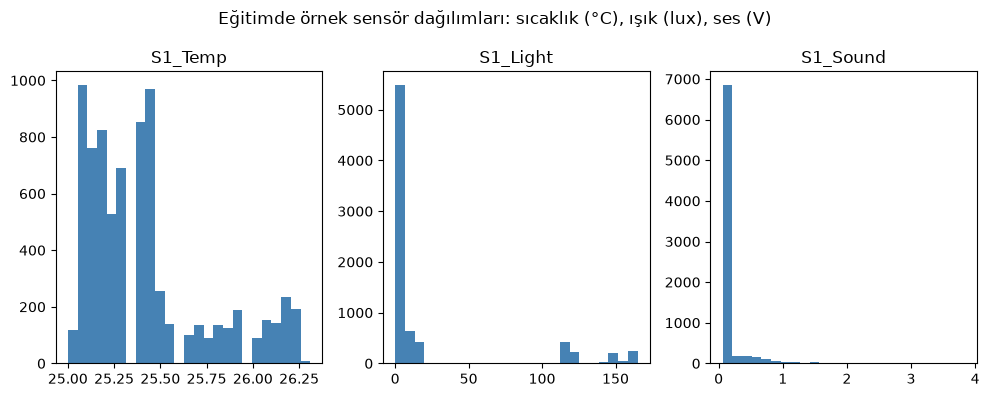

In [31]:
display(X_train[sayisal_sutunlar].describe().T[['mean', 'std', 'min', 'max']].round(2))
X_train[['S1_Temp', 'S1_Light', 'S1_Sound']].hist(
    bins=25, figsize=(10, 4), layout=(1, 3), color='steelblue', grid=False)
plt.suptitle('Eğitimde örnek sensör dağılımları: sıcaklık (°C), ışık (lux), ses (V)')
plt.tight_layout()
plt.savefig(sekil_klasoru / '02_sensor_dagilimlari.png')
plt.show()

## 5. Çapraz doğrulama
Model seçimi için eğitim verisinde 3 katlı çapraz doğrulama kullandım. Her denemede model iki parçadan öğrenirken kalan parçada değerlendiriliyor.
Üç skorun ortalamasını karşılaştırdım; en yüksek sonucu veren veri bölmesini seçmedim.
Sınıflandırma ve regresyonda aynı bölmeleri kullandım. Test verisini bu aşamaya dahil etmedim.

In [ ]:
# Eğitim verilerini 3 katlı StratifiedGroupKFold ile çapraz doğrulama için bölüyoruz.
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_bolmeleri = []
egitim_bloklari = veri.loc[egitim_index, 'blok']

for train_sira, val_sira in cv.split(X_train, y_sinif_train, groups=egitim_bloklari):
    train_asil = X_train.iloc[train_sira].index
    val_asil = X_train.iloc[val_sira].index
    kalan_index = yakin_kayitlari_cikar(train_asil, val_asil)

    # cross_val_score tekrar X_train içindeki satır sıralarını bekliyor.
    kalan_sira = X_train.index.get_indexer(kalan_index)
    cv_bolmeleri.append((kalan_sira, val_sira))

    # her katmanda tüm sınıflar mevcut olmalı
    assert set(y_sinif_train.iloc[kalan_sira]) == {0, 1, 2, 3}
    assert set(y_sinif_train.iloc[val_sira]) == {0, 1, 2, 3}

## 6. Ölçekleme
Sıcaklık, ışık ve ses farklı ölçeklerde olduğu için sayısal sütunlara `StandardScaler` uyguladım. PIR sütunlarını 0/1 olarak bıraktım.
Ölçekleyici ile modeli `Pipeline` içinde birleştirdim. Böylece ölçekleme parametreleri her CV denemesinde yalnız o denemenin eğitim kısmından öğreniliyor.
Bütün veriyi önceden ölçekleseydim doğrulama ve test bilgisini eğitime taşımış olurdum.

In [ ]:
def model_hazirla(model):
    olcekleme = ColumnTransformer(
        [('sayisal', StandardScaler(), sayisal_sutunlar)],
        remainder='passthrough'
    )
    return make_pipeline(olcekleme, model)

## 7. Sınıflandırma modelleri
Baseline olarak en sık sınıfı söyleyen modeli kullandım. Lojistik regresyon ile iki ANN mimarisini karşılaştırdım:
32 nöronlu tek gizli katman ve 64–32 nöronlu iki gizli katman.

Model seçiminde ortalama CV macro-F1 skorunu kullandım. Lojistik regresyonun C=10 değerini önceki eğitim CV denemelerinden korudum.
Zaman bloklarından bağımsız rastgele bir doğrulama ayrımı yapmaması için ANN'de `early_stopping` kullanmadım.

In [11]:
sinif_modelleri = {
    'Baseline': DummyClassifier(strategy='most_frequent'),
    'Lojistik Regresyon': LogisticRegression(C=10, max_iter=2000, random_state=SEED),
    'ANN 32': MLPClassifier(hidden_layer_sizes=(32,), max_iter=600,
                           batch_size=128, alpha=0.001, n_iter_no_change=30,
                           early_stopping=False, random_state=SEED),
    'ANN 64-32': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600,
                              batch_size=128, alpha=0.001, n_iter_no_change=30,
                              early_stopping=False, random_state=SEED)
}

sinif_pipeline = {}
sinif_cv_sonuclari = []
for isim, model in sinif_modelleri.items():
    pipeline = model_hazirla(model)
    skorlar = cross_val_score(pipeline, X_train, y_sinif_train,
                             cv=cv_bolmeleri, scoring='f1_macro')
    sinif_pipeline[isim] = pipeline
    sinif_cv_sonuclari.append([isim, skorlar.mean(), skorlar.std()])

sinif_cv = pd.DataFrame(sinif_cv_sonuclari, columns=['Model', 'CV F1', 'CV std'])
en_iyi_sinif = sinif_cv.loc[sinif_cv['CV F1'].idxmax(), 'Model']
display(sinif_cv.round(4))
print('CV ile seçilen:', en_iyi_sinif)

,Model,CV F1,CV std
0,Baseline,0.2260,0.0019
1,Lojistik Regresyon,0.7842,0.1635
2,ANN 32,0.7780,0.1045
3,ANN 64-32,0.7863,0.0905


CV ile seçilen: ANN 64-32


### ANN mimarilerinin karşılaştırılması
İki mimarinin ortalama CV skorlarını karşılaştırdım. Tablodaki standart sapma, üç katın skorlarının ne kadar değiştiğini gösteriyor; güven aralığı değil.

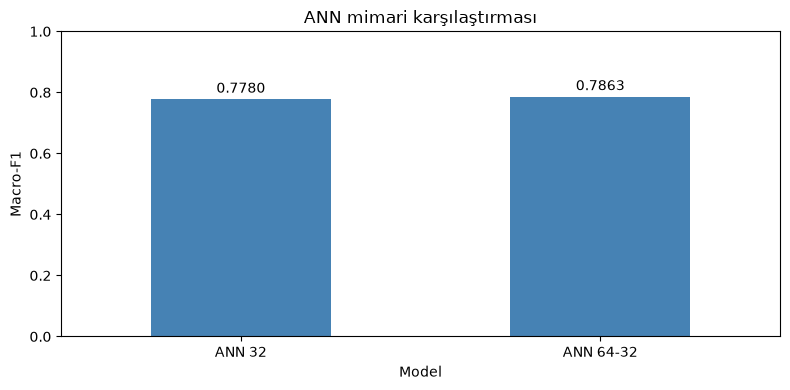

In [37]:
ann_sonuclari = sinif_cv[sinif_cv['Model'].str.startswith('ANN')]
ann_sonuclari.plot.bar(x='Model', y='CV F1', legend=False, rot=0, color='steelblue')
plt.ylim(0, 1); plt.ylabel('Macro-F1'); plt.title('ANN mimari karşılaştırması')
for i, v in enumerate(ann_sonuclari['CV F1']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(sekil_klasoru / '03_ann_karsilastirma.png')
plt.show()

## 8. Regresyon modelleri
Regresyonda aynı andaki CO₂ miktarını tahmin ettim; gelecekteki CO₂ değerini tahmin etmeyi amaçlamadım.
Baseline olarak eğitim hedefinin ortalamasını kullandım. Ridge ve Random Forest modellerini ortalama CV RMSE ile karşılaştırdım.
Ridge için alpha=10, Random Forest için derinlik=8 ve minimum yaprak örnek sayısı=2 ayarlarını önceki eğitim CV denemelerinden korudum.
Scikit-learn RMSE skorunu negatif döndürdüğü için işaretini çevirdim. Daha düşük RMSE'yi daha iyi kabul ettim.

In [13]:
reg_modelleri = {
    'Baseline': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=120, max_depth=8,
                                          min_samples_leaf=2, random_state=SEED)
}

reg_pipeline = {}
reg_cv_sonuclari = []
for isim, model in reg_modelleri.items():
    pipeline = model_hazirla(model)
    skorlar = -cross_val_score(pipeline, X_train, y_reg_train,
                              cv=cv_bolmeleri, scoring='neg_root_mean_squared_error')
    reg_pipeline[isim] = pipeline
    reg_cv_sonuclari.append([isim, skorlar.mean(), skorlar.std()])

reg_cv = pd.DataFrame(reg_cv_sonuclari, columns=['Model', 'CV RMSE', 'CV std'])
en_iyi_reg = reg_cv.loc[reg_cv['CV RMSE'].idxmin(), 'Model']
display(reg_cv.round(3))
print('CV ile seçilen:', en_iyi_reg)

,Model,CV RMSE,CV std
0,Baseline,169.236,51.369
1,Ridge,100.701,30.719
2,Random Forest,55.237,26.885


CV ile seçilen: Random Forest


## 9. Sınıflandırma sonuçları
CV karşılaştırmasından sonra modelleri eğitim verisinin tamamıyla yeniden eğittim.
Eğitim ve test için accuracy, precision, recall ve F1 hesapladım. Precision, recall ve F1 için macro ortalama kullandım.
Testteki sıralamaya bakarak model seçimimi veya ayarları değiştirmedim.

In [14]:
sinif_sonuclari = []
sinif_tahminleri = {}

for isim, pipeline in sinif_pipeline.items():
    pipeline.fit(X_train, y_sinif_train)
    egitim_tahmini = pipeline.predict(X_train)
    test_tahmini = pipeline.predict(X_test)
    sinif_tahminleri[isim] = test_tahmini

    for bolum, gercek, tahmin in [('Eğitim', y_sinif_train, egitim_tahmini),
                                 ('Test', y_sinif_test, test_tahmini)]:
        sinif_sonuclari.append({
            'Model': isim, 'Bölüm': bolum,
            'Accuracy': accuracy_score(gercek, tahmin),
            'Precision': precision_score(gercek, tahmin, average='macro', zero_division=0),
            'Recall': recall_score(gercek, tahmin, average='macro', zero_division=0),
            'F1': f1_score(gercek, tahmin, average='macro', zero_division=0)
        })

sinif_sonuc = pd.DataFrame(sinif_sonuclari)
display(sinif_sonuc.round(4))

,Model,Bölüm,Accuracy,Precision,Recall,F1
0,Baseline,Eğitim,0.8247,0.2062,0.2500,0.2260
1,Baseline,Test,0.7996,0.1999,0.2500,0.2222
2,Lojistik Regresyon,Eğitim,0.9948,0.9813,0.9818,0.9815
3,Lojistik Regresyon,Test,0.9787,0.9449,0.9885,0.9645
4,ANN 32,Eğitim,0.9991,0.9969,0.9965,0.9967
5,ANN 32,Test,0.9939,0.9737,0.9804,0.9769
6,ANN 64-32,Eğitim,1.0000,1.0000,1.0000,1.0000
7,ANN 64-32,Test,0.9585,0.8596,0.9441,0.8940


In [15]:
# CV, eğitim ve test karşılaştırması
sinif_ozet = sinif_sonuc.pivot(index='Model', columns='Bölüm', values='F1')
sinif_ozet = sinif_ozet.join(sinif_cv.set_index('Model')[['CV F1']])
sinif_ozet['F1 farkı'] = sinif_ozet['Eğitim'] - sinif_ozet['Test']
display(sinif_ozet[['CV F1', 'Eğitim', 'Test', 'F1 farkı']].round(4))

,CV F1,Eğitim,Test,F1 farkı
Model,,,,
ANN 32,0.7780,0.9967,0.9769,0.0198
ANN 64-32,0.7863,1.0000,0.8940,0.1060
Baseline,0.2260,0.2260,0.2222,0.0038
Lojistik Regresyon,0.7842,0.9815,0.9645,0.0170


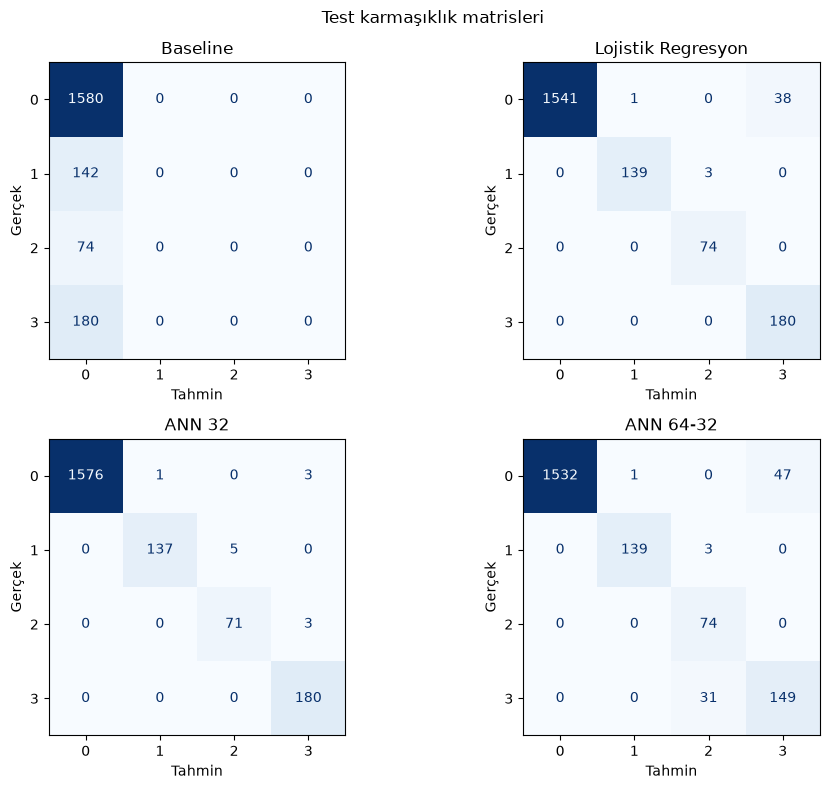

In [16]:
fig, eksenler = plt.subplots(2, 2, figsize=(10, 8))
for eksen, (isim, tahmin) in zip(eksenler.ravel(), sinif_tahminleri.items()):
    ConfusionMatrixDisplay.from_predictions(y_sinif_test, tahmin, labels=[0, 1, 2, 3],
                                           ax=eksen, colorbar=False, cmap='Blues')
    eksen.set_title(isim)
    eksen.set_xlabel('Tahmin'); eksen.set_ylabel('Gerçek')
plt.suptitle('Test karmaşıklık matrisleri')
plt.tight_layout()
plt.savefig(sekil_klasoru / '04_karmasiklik_matrisleri.png')
plt.show()

## 10. Regresyon sonuçları
Eğitim ve test için MAE, MSE, RMSE ve R² hesapladım.
MAE ve RMSE'yi ppm, MSE'yi ppm² cinsinden değerlendirdim. R² birimsizdir; negatif değer alması, ilgili bölmenin hedef ortalamasını tahmin etmekten daha kötü sonuca işaret eder.

In [17]:
reg_sonuclari = []
reg_tahminleri = {}

for isim, pipeline in reg_pipeline.items():
    pipeline.fit(X_train, y_reg_train)
    egitim_tahmini = pipeline.predict(X_train)
    test_tahmini = pipeline.predict(X_test)
    reg_tahminleri[isim] = test_tahmini

    for bolum, gercek, tahmin in [('Eğitim', y_reg_train, egitim_tahmini),
                                 ('Test', y_reg_test, test_tahmini)]:
        mse = mean_squared_error(gercek, tahmin)
        reg_sonuclari.append({
            'Model': isim, 'Bölüm': bolum,
            'MAE': mean_absolute_error(gercek, tahmin),
            'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(gercek, tahmin)
        })

reg_sonuc = pd.DataFrame(reg_sonuclari)
display(reg_sonuc.round(3))

,Model,Bölüm,MAE,MSE,RMSE,R2
0,Baseline,Eğitim,119.216,28180.885,167.872,0.000
1,Baseline,Test,192.324,81913.528,286.205,-0.171
2,Ridge,Eğitim,44.021,4053.946,63.671,0.856
3,Ridge,Test,103.333,18549.046,136.195,0.735
4,Random Forest,Eğitim,3.212,42.775,6.540,0.998
5,Random Forest,Test,47.353,5933.816,77.031,0.915


In [18]:
# Metrikleri eğitim / test olarak yan yana gösterdim.
reg_ozet = reg_cv.set_index('Model')[['CV RMSE']].copy()
for metrik in ['MAE', 'MSE', 'RMSE', 'R2']:
    tablo = reg_sonuc.pivot(index='Model', columns='Bölüm', values=metrik)
    reg_ozet[metrik + ' (eğitim / test)'] = (
        tablo['Eğitim'].round(3).astype(str) + ' / ' + tablo['Test'].round(3).astype(str)
    )
display(reg_ozet.round(3))

,CV RMSE,MAE (eğitim / test),MSE (eğitim / test),RMSE (eğitim / test),R2 (eğitim / test)
Model,,,,,
Baseline,169.236,119.216 / 192.324,28180.885 / 81913.528,167.872 / 286.205,0.0 / -0.171
Ridge,100.701,44.021 / 103.333,4053.946 / 18549.046,63.671 / 136.195,0.856 / 0.735
Random Forest,55.237,3.212 / 47.353,42.775 / 5933.816,6.54 / 77.031,0.998 / 0.915


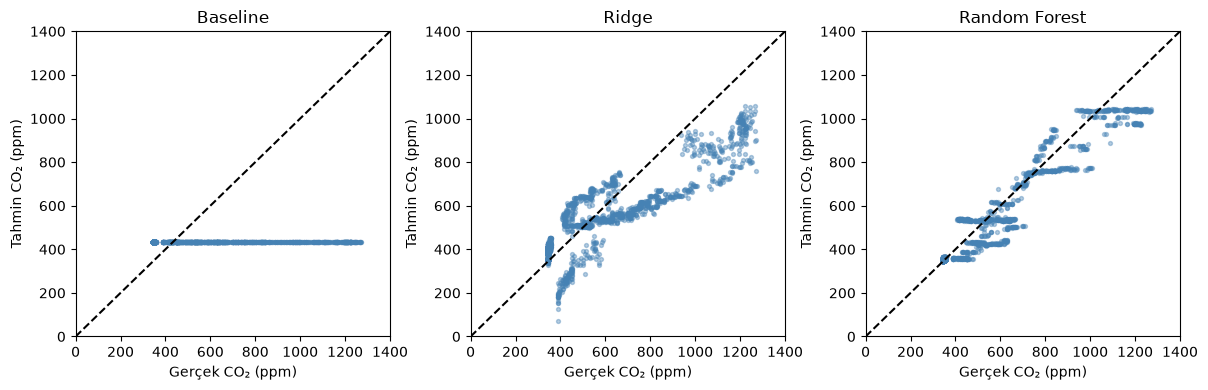

In [19]:
fig, eksenler = plt.subplots(1, 3, figsize=(12, 4))
for eksen, (isim, tahmin) in zip(eksenler, reg_tahminleri.items()):
    eksen.scatter(y_reg_test, tahmin, s=8, alpha=0.4, color='steelblue')
    eksen.plot([0, 1400], [0, 1400], '--', color='black')
    eksen.set_xlim(0, 1400); eksen.set_ylim(0, 1400)
    eksen.set_title(isim)
    eksen.set_xlabel('Gerçek CO₂ (ppm)'); eksen.set_ylabel('Tahmin CO₂ (ppm)')
plt.tight_layout()
plt.savefig(sekil_klasoru / '05_gercek_tahmin.png')
plt.show()

## 11. Kümeleme
Kümelemede hedef sütunlarını kullanmadan benzer sensör ölçümlerini grupladım. Önceden verilmiş doğru küme etiketleri olmadığı için bu bölümde gözetimsiz öğrenme uyguladım.
KMeans uzaklığa dayandığı için sayısal özellikleri yalnız eğitim verisinden öğrendiğim parametrelerle ölçekledim.
2–8 arasındaki küme sayılarını denedim; seçimde silhouette skorunu kullandım ve dirsek grafiğini de inceledim.
Aynı türden birden fazla sensörün uzaklık hesabında o bilgiye daha fazla ağırlık verebileceğini bir sınırlama olarak değerlendirdim.

In [20]:
kume_olcekleme = ColumnTransformer(
    [('sayisal', StandardScaler(), sayisal_sutunlar)], remainder='passthrough'
)
X_kume = kume_olcekleme.fit_transform(X_train)

# Silhouette hesabını hızlandırmak için her k'da aynı 2.000 kayıt kullanılır.
rng = np.random.default_rng(SEED)
ornek_index = rng.choice(len(X_kume), size=2000, replace=False)
kume_modelleri = {}
kume_sonuclari = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    etiketler = model.fit_predict(X_kume)
    silhouette = silhouette_score(X_kume[ornek_index], etiketler[ornek_index])
    kume_modelleri[k] = model
    kume_sonuclari.append([k, model.inertia_, silhouette])

kume_sonuc = pd.DataFrame(kume_sonuclari, columns=['k', 'Inertia', 'Silhouette'])
en_iyi_k = int(kume_sonuc.loc[kume_sonuc['Silhouette'].idxmax(), 'k'])
display(kume_sonuc.round(3))
print('Silhouette ile seçilen k:', en_iyi_k)

,k,Inertia,Silhouette
0,2,52194.575,0.632
1,3,42993.612,0.610
2,4,36922.075,0.361
3,5,32166.051,0.378
4,6,28660.366,0.434
5,7,26275.455,0.435
6,8,24012.463,0.441


Silhouette ile seçilen k: 2


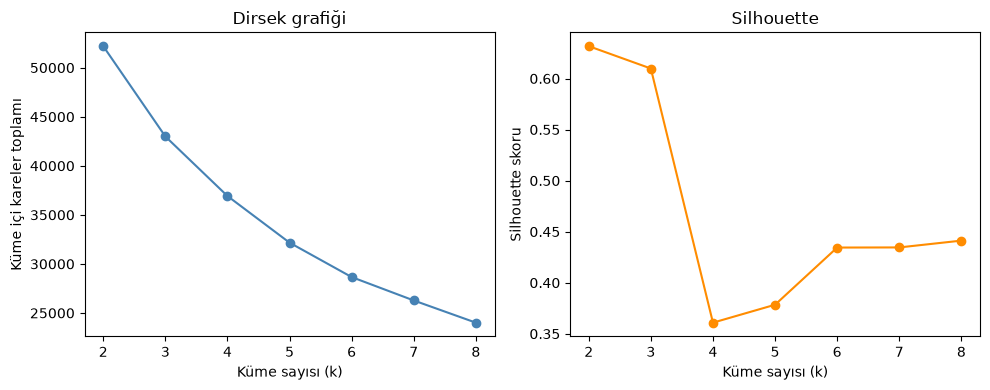

In [21]:
fig, eksenler = plt.subplots(1, 2, figsize=(10, 4))
eksenler[0].plot(kume_sonuc['k'], kume_sonuc['Inertia'], 'o-', color='steelblue')
eksenler[0].set_title('Dirsek grafiği'); eksenler[0].set_ylabel('Küme içi kareler toplamı')
eksenler[1].plot(kume_sonuc['k'], kume_sonuc['Silhouette'], 'o-', color='darkorange')
eksenler[1].set_title('Silhouette'); eksenler[1].set_ylabel('Silhouette skoru')
for eksen in eksenler:
    eksen.set_xlabel('Küme sayısı (k)')
plt.tight_layout()
plt.savefig(sekil_klasoru / '06_kume_secimi.png')
plt.show()

### Küme profilleri
Kümeleri yorumlamak için sensör ortalamalarını özgün birimlerinde karşılaştırdım.
PIR ortalamasını, kümedeki kayıtlarda hareket algılanma oranı olarak değerlendirdim.

Küme,0,1
S1_Temp,26.022,25.288
S2_Temp,26.240,25.305
S3_Temp,25.680,24.861
S4_Temp,26.230,25.634
S1_Light,118.854,2.966
S2_Light,112.249,2.783
S3_Light,140.255,12.027
S4_Light,33.614,8.307
S1_Sound,0.509,0.079
S2_Sound,0.391,0.056


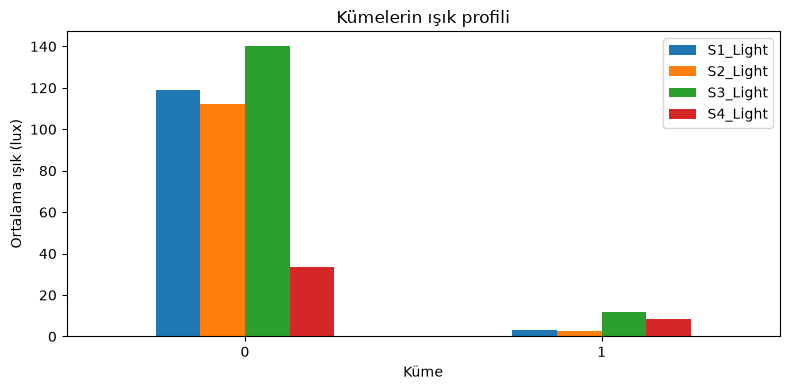

In [22]:
profil = X_train.copy()
profil['Küme'] = kume_modelleri[en_iyi_k].labels_
kume_profili = profil.groupby('Küme')[ozellikler].mean()
kume_profili['Kayıt'] = profil.groupby('Küme').size()
display(kume_profili.T.round(3))

kume_profili[['S1_Light', 'S2_Light', 'S3_Light', 'S4_Light']].plot.bar(rot=0)
plt.ylabel('Ortalama ışık (lux)'); plt.title('Kümelerin ışık profili')
plt.tight_layout()
plt.savefig(sekil_klasoru / '07_kume_profili.png')
plt.show()

## 12. Sonuç ve değerlendirme
Sınıflandırmada ANN (64,32) modelini CV macro-F1 ortalaması 0,786 olduğu için seçtim.
Tek katmanlı ANN'nin CV skoru 0,778; mimari değişikliğiyle yaklaşık 0,008 artış elde ettim.
Lojistik regresyonun CV skoru 0,784 olduğu için iki model arasındaki küçük farkı kesin üstünlük olarak yorumlamadım.

Baseline'ın test F1 skoru 0,222 iken lojistik regresyonda 0,964, ANN (32)'de 0,977 ve ANN (64,32)'de 0,894 elde ettim.
Lojistik regresyonun eğitim F1 skoru 0,982, ANN (32)'nin 0,997; testle farklarını daha küçük buldum.
Büyük ANN'nin eğitim F1 skoru 1,000 olduğu için 0,894'lük test sonucuyla arasındaki farkı aşırı uyum belirtisi olarak değerlendirdim.
Testte diğer modeller daha iyi sonuç verse de CV ile yaptığım seçimi değiştirmedim.

Regresyonda Random Forest'ı CV RMSE değeri 55,2 ppm olduğu için seçtim.
Test RMSE değerlerini baseline için 286,2, Ridge için 136,2 ve Random Forest için 77,0 ppm buldum.
Baseline'ın test R² değeri negatifken Ridge'de 0,735, Random Forest'ta 0,915 elde ettim.
Ridge'in eğitim RMSE'si 63,7, Random Forest'ın ise 6,5 ppm olduğundan özellikle Random Forest'ta eğitim-test farkını belirgin buldum.
Bu farkı aşırı uyum olasılığıyla birlikte zaman bloklarının farklı koşullar içermesi açısından da değerlendirdim.
Öğrenen modeller baseline'ı geçtiği için genel bir eksik uyum sonucu çıkarmadım.

Kümelemede en yüksek silhouette skorunu yaklaşık 0,632 ile k=2 için elde ettim. Dirsek grafiğinde belirgin tek bir kırılma görmediğim için silhouette sonucunu esas aldım.
1.311 kayıtlık kümede ışık, ses ve hareket daha yüksek; 6.409 kayıtlık kümede ortam daha karanlık ve sessizdi.
Bu grupları doğrudan kişi sayısı olarak değil, ortam koşulları olarak yorumladım.

Aynı girdilerden kişi sayısını kategorik hedef, CO₂'yi sürekli hedef olarak ele alarak iki farklı tahmin problemi kurdum; hedef kullanmadan da ortam grupları elde ettim.
Veri tek odadan ve yedi tarihten geldiği için sonuçları yeni odalara veya gelecekteki günlere genellemedim.

## 13. Sonuçların kaydedilmesi
Sonuç tablolarını CSV olarak, grafikleri PNG olarak `outputs` klasörüne kaydettim.

In [23]:
sinif_cv.to_csv(sonuc_klasoru / 'siniflandirma_cv.csv', index=False)
sinif_sonuc.to_csv(sonuc_klasoru / 'siniflandirma_metrikler.csv', index=False)
sinif_ozet.to_csv(sonuc_klasoru / 'siniflandirma_ozet.csv')
reg_cv.to_csv(sonuc_klasoru / 'regresyon_cv.csv', index=False)
reg_sonuc.to_csv(sonuc_klasoru / 'regresyon_metrikler.csv', index=False)
reg_ozet.to_csv(sonuc_klasoru / 'regresyon_ozet.csv')
kume_sonuc.to_csv(sonuc_klasoru / 'kume_secimi.csv', index=False)
kume_profili.to_csv(sonuc_klasoru / 'kume_profili.csv')

## Kaynaklar
- Singh, A. ve Chaudhari, S. (2018). [Room Occupancy Estimation — UCI](https://doi.org/10.24432/C5P605). CC BY 4.0.
- Scikit-learn: [Ön işleme ve veri sızıntısı](https://scikit-learn.org/stable/common_pitfalls.html).
- Scikit-learn: [Çapraz doğrulama](https://scikit-learn.org/stable/modules/cross_validation.html).